In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import export_text, plot_tree

In [ ]:
df = pd.read_excel("Dataset_after_cleaning.xlsx")
df_dd = df.drop(columns=['ReturningVisitor', 'OtherVisitor', 'BounceRates', 'Region1', 'Month_5', 'OperatingSystem2', 'Browser2', 'PageValues'])
df_dd

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,SpecialDay,Month_2,Month_3,...,Region5,Region6,Region7,Region8,Region9,NewVisitor,IfWeekend,Y_IfRevenue,OperatingSystemOther,BrowserOther
0,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.100000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,1,0,0,0,1,0
3,0,0.0,0,0.0,2,2.666667,0.140000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.050000,0.0,1,0,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.029031,0.0,0,0,...,0,0,0,0,0,0,1,0,1,1
12326,0,0.0,0,0.0,5,465.750000,0.021333,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12327,0,0.0,0,0.0,6,184.250000,0.086667,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12328,4,75.0,0,0.0,15,346.000000,0.021053,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_dd.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'ExitRates', 'SpecialDay', 'Month_2', 'Month_3', 'Month_6', 'Month_7',
       'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'OperatingSystem1', 'OperatingSystem3', 'Browser1', 'Region2',
       'Region3', 'Region4', 'Region5', 'Region6', 'Region7', 'Region8',
       'Region9', 'NewVisitor', 'IfWeekend', 'Y_IfRevenue',
       'OperatingSystemOther', 'BrowserOther'],
      dtype='object')

In [4]:
X = df_dd.drop('Y_IfRevenue', axis=1)
Y = df_dd['Y_IfRevenue']

#podział na zbiór testowy i walidacyjny
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.30, random_state=42, stratify=Y_train_val)

# Trenowanie modelu

In [5]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=1
)
dt.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [6]:
Y_val_pred = dt.predict(X_val)

#Macierz pomyłek
print(confusion_matrix(Y_val, Y_val_pred))

#raport klasyfikacji
print(classification_report(Y_val, Y_val_pred))

[[1872  317]
 [ 292  109]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      2189
           1       0.26      0.27      0.26       401

    accuracy                           0.76      2590
   macro avg       0.56      0.56      0.56      2590
weighted avg       0.77      0.76      0.77      2590



# Zależność max depth a recall na train i val

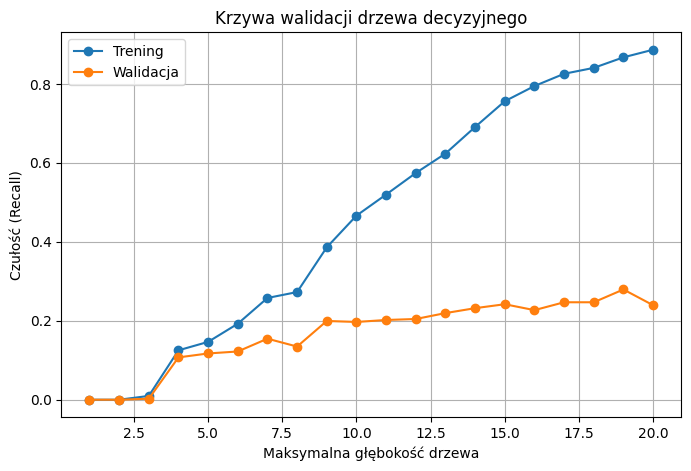

In [7]:
# Lista wartości max_depth do przetestowania
max_depth_values = np.arange(1, 21)  # od 1 do 20

# Listy do przechowywania wyników
train_recalls = []
val_recalls = []

# Pętla po różnych głębokościach drzewa
for depth in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, Y_train)
    
     # Recall na zbiorze treningowym
    train_recall = recall_score(Y_train, dt.predict(X_train))
    train_recalls.append(train_recall)
    
    # Recall na zbiorze walidacyjnym
    val_recall = recall_score(Y_val, dt.predict(X_val))
    val_recalls.append(val_recall)


# Wizualizacja
plt.figure(figsize=(8,5))
plt.plot(max_depth_values, train_recalls, label='Trening', marker='o')
plt.plot(max_depth_values, val_recalls, label='Walidacja', marker='o')
plt.xlabel('Maksymalna głębokość drzewa')
plt.ylabel('Czułość (Recall)')
plt.title('Krzywa walidacji drzewa decyzyjnego')
plt.legend()
plt.grid(True)
plt.show()

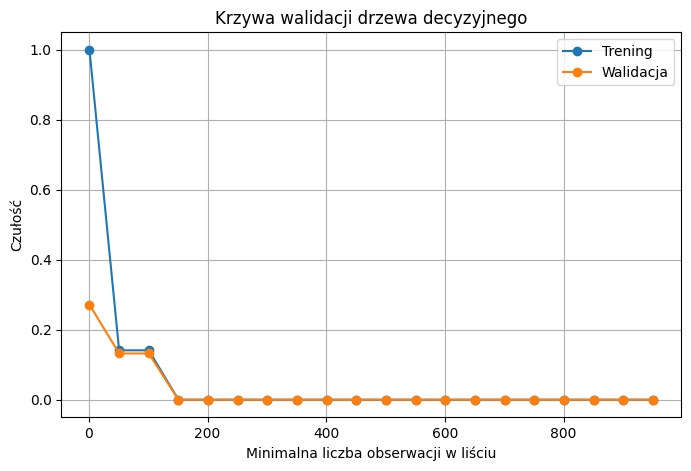

In [8]:
# Lista wartości min_samples_leaf do przetestowania
min_samples_leaf_values = np.arange(1, 1000, 50)  # od 1 do 20

# Listy do przechowywania wyników
train_recalls = []
val_recalls = []

# Pętla po różnych wartościach min_samples_leaf
for leaf_size in min_samples_leaf_values:
    dt = DecisionTreeClassifier(
        min_samples_leaf=leaf_size,
        random_state=42
    )
    dt.fit(X_train, Y_train)
    
    # Czułość na zbiorze treningowym
    train_recall = recall_score(Y_train, dt.predict(X_train))
    train_recalls.append(train_recall)
    
    # Czułość na zbiorze walidacyjnym
    val_recall = recall_score(Y_val, dt.predict(X_val))
    val_recalls.append(val_recall)

# Wizualizacja
plt.figure(figsize=(8,5))
plt.plot(min_samples_leaf_values, train_recalls, label='Trening', marker='o')
plt.plot(min_samples_leaf_values, val_recalls, label='Walidacja', marker='o')
plt.xlabel('Minimalna liczba obserwacji w liściu')
plt.ylabel('Czułość')
plt.title('Krzywa walidacji drzewa decyzyjnego')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.tree import plot_tree

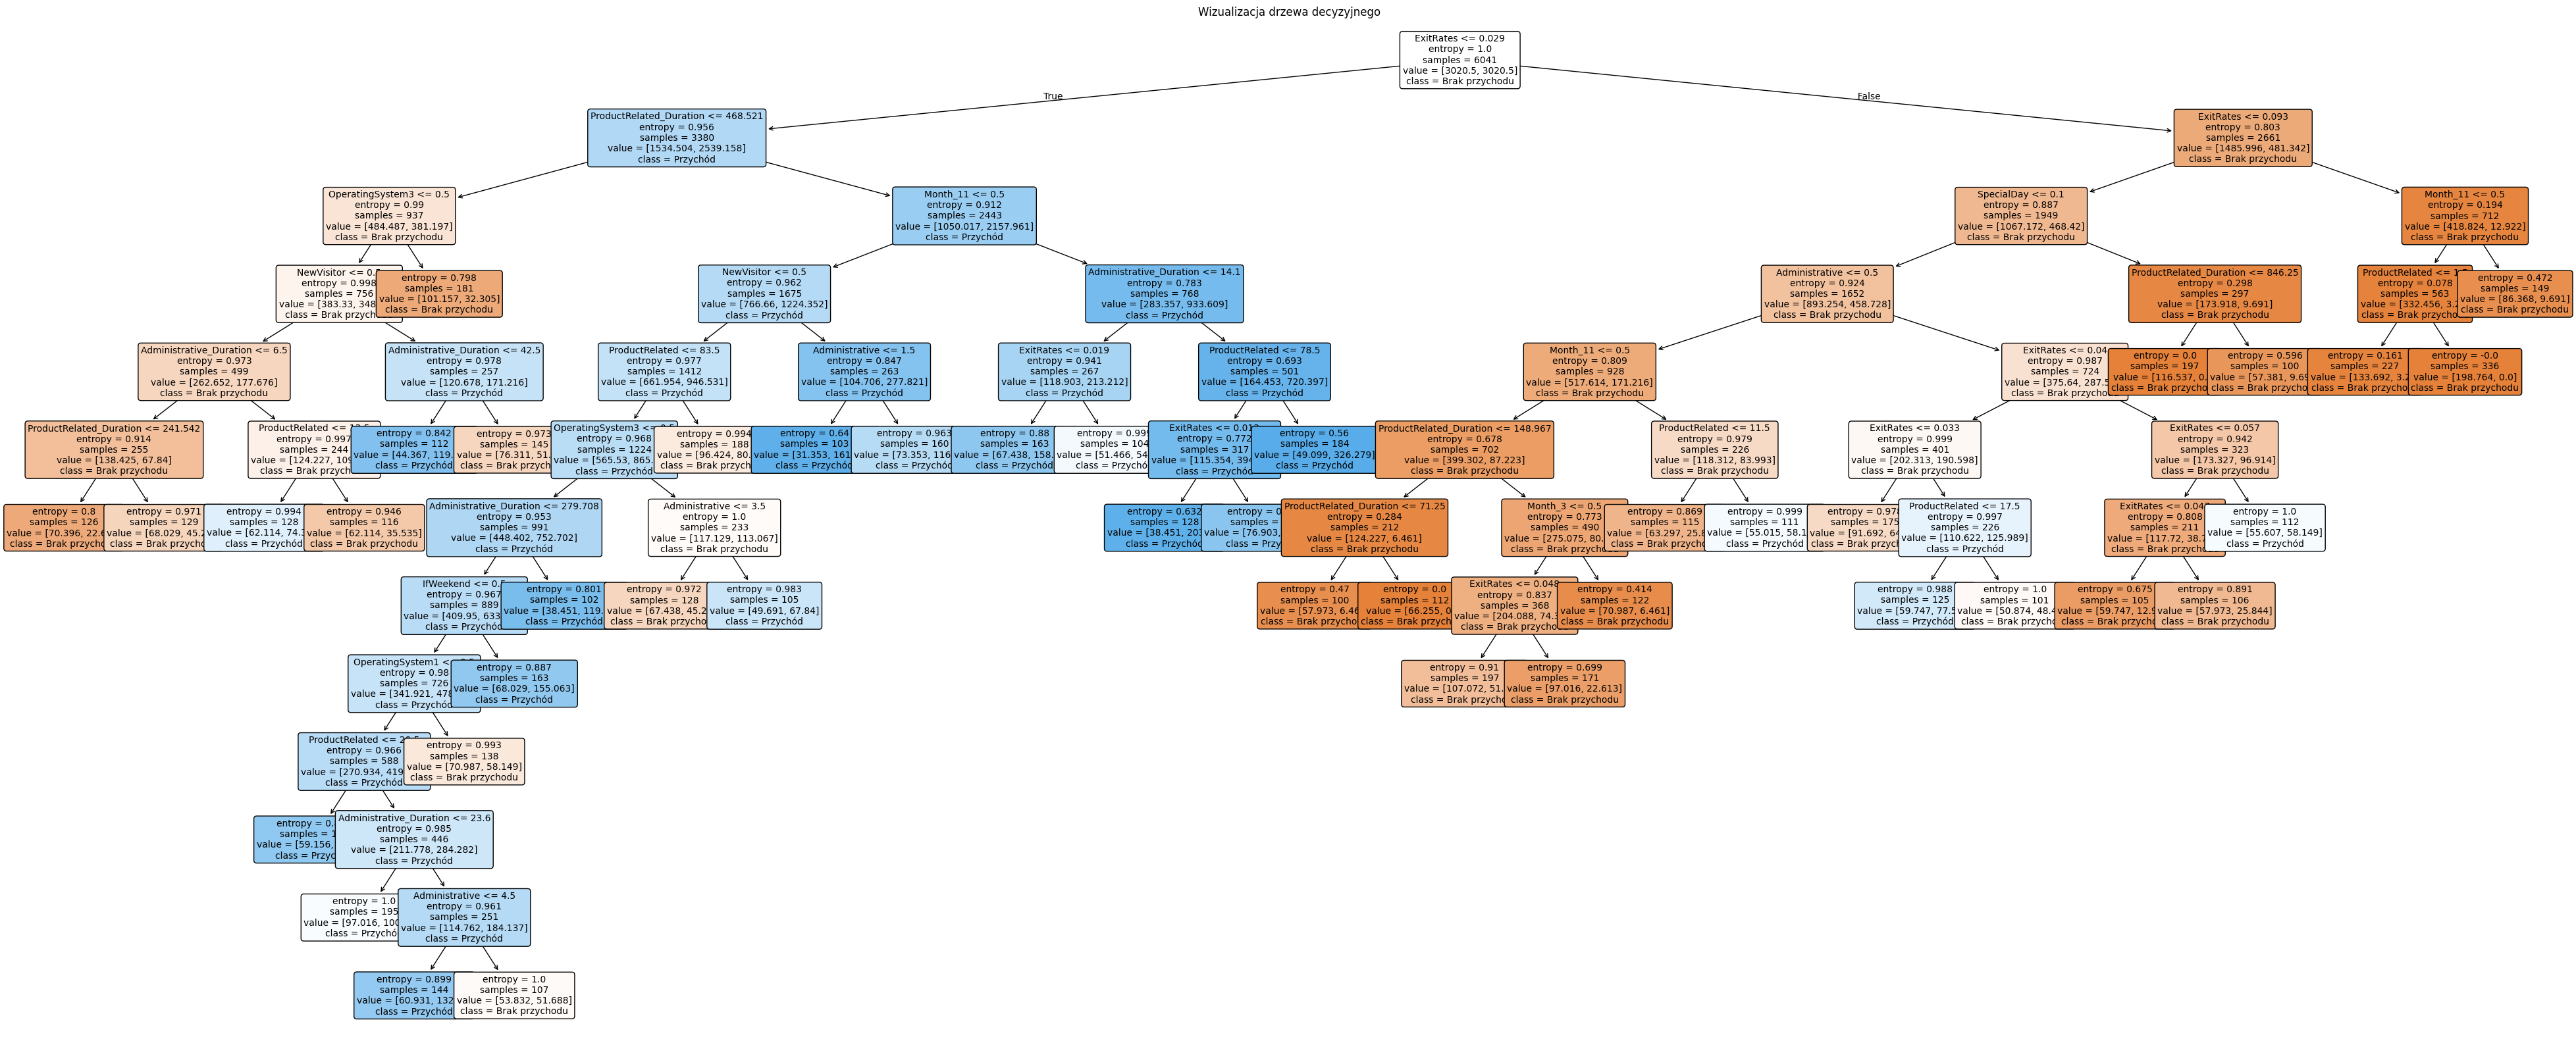

In [10]:
#drzewo decyzyjne dla min leaf samples 100 i wizualizacja

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=100,
    class_weight='balanced',
    criterion='entropy'
)
dt.fit(X_train, Y_train)

plt.figure(figsize=(50, 20))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=['Brak przychodu', 'Przychód'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Wizualizacja drzewa decyzyjnego')
plt.show()

In [11]:
#raport klasyfikacji i macierz pomyłek

Y_val_pred = dt.predict(X_val)

print(confusion_matrix(Y_val, Y_val_pred))

print(classification_report(Y_val, Y_val_pred))

[[1446  743]
 [ 118  283]]
              precision    recall  f1-score   support

           0       0.92      0.66      0.77      2189
           1       0.28      0.71      0.40       401

    accuracy                           0.67      2590
   macro avg       0.60      0.68      0.58      2590
weighted avg       0.82      0.67      0.71      2590



# Sprawdzam różne strategie aby max recall

C:\Users\sonet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sonet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Najlepszy próg (F1): 0.590
Recall: 0.559
Precision: 0.348
F1-score: 0.429

Najlepszy próg dla recall >= 0.75:
Threshold: 0.427
Recall: 0.800
Precision: 0.249


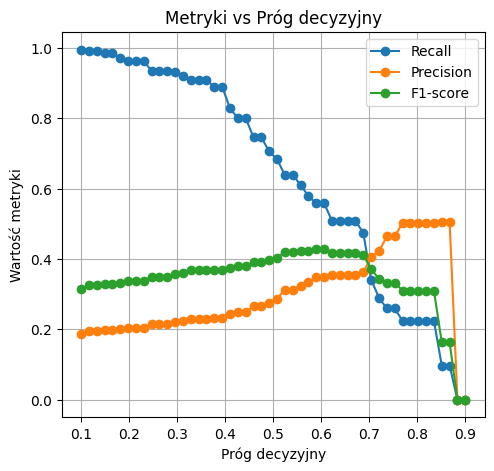

In [12]:
# Strategia 2: Regulacja progu decyzyjnego (threshold tuning)
# Zamiast używać domyślnego progu 0.5, szukamy optymalnego

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=100,
    class_weight='balanced',
    criterion='entropy'
)
dt.fit(X_train, Y_train)

# Pobieramy prawdopodobieństwa przewidywań
y_proba_val = dt.predict_proba(X_val)[:, 1]

# Testujemy różne progi
thresholds = np.linspace(0.1, 0.9, 50)
threshold_results = []

for threshold in thresholds:
    y_val_pred_threshold = (y_proba_val >= threshold).astype(int)
    
    recall = recall_score(Y_val, y_val_pred_threshold)
    precision = precision_score(Y_val, y_val_pred_threshold)
    f1 = f1_score(Y_val, y_val_pred_threshold)
    
    threshold_results.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

# Znajdź próg z najlepszym F1 score
best_f1_idx = threshold_df['f1'].idxmax()
best_threshold = threshold_df.loc[best_f1_idx, 'threshold']
print(f"Najlepszy próg (F1): {best_threshold:.3f}")
print(f"Recall: {threshold_df.loc[best_f1_idx, 'recall']:.3f}")
print(f"Precision: {threshold_df.loc[best_f1_idx, 'precision']:.3f}")
print(f"F1-score: {threshold_df.loc[best_f1_idx, 'f1']:.3f}")

# Znajdź próg dla recall > 0.75 z najlepszą precyzją
high_recall_df = threshold_df[threshold_df['recall'] >= 0.75]
if len(high_recall_df) > 0:
    best_precision_idx = high_recall_df['precision'].idxmax()
    print(f"\nNajlepszy próg dla recall >= 0.75:")
    print(f"Threshold: {high_recall_df.loc[best_precision_idx, 'threshold']:.3f}")
    print(f"Recall: {high_recall_df.loc[best_precision_idx, 'recall']:.3f}")
    print(f"Precision: {high_recall_df.loc[best_precision_idx, 'precision']:.3f}")

# Wizualizacja krzywej Precision-Recall
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', marker='o')
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', marker='o')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1-score', marker='o')
plt.xlabel('Próg decyzyjny')
plt.ylabel('Wartość metryki')
plt.title('Metryki vs Próg decyzyjny')
plt.legend()
plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.plot(threshold_df['recall'], threshold_df['precision'], marker='o')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Krzywa Precision-Recall')
# plt.grid(True)

# plt.tight_layout()
plt.show()

# Finalny model - najlepsze parametry dla maksymalizacji Recall

FINALNY MODEL - WYNIKI NA ZBIORZE WALIDACYJNYM:
Parametry: class_weight={0: 1, 1: 7}, min_samples_leaf=100

Macierz pomyłek:
[[1173 1016]
 [  79  322]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.94      0.54      0.68      2189
           1       0.24      0.80      0.37       401

    accuracy                           0.58      2590
   macro avg       0.59      0.67      0.53      2590
weighted avg       0.83      0.58      0.63      2590

              precision    recall  f1-score   support

           0       0.94      0.54      0.68      2189
           1       0.24      0.80      0.37       401

    accuracy                           0.58      2590
   macro avg       0.59      0.67      0.53      2590
weighted avg       0.83      0.58      0.63      2590



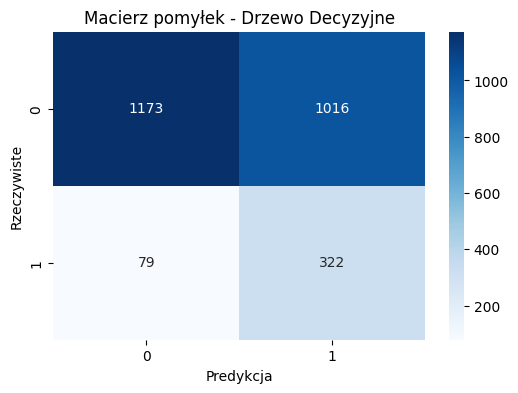

In [13]:
# Model z najlepszymi parametrami (najwyższy recall)
dt = DecisionTreeClassifier(
    class_weight={0: 1, 1: 7},  # Zmień tę wagę aby przetestować różne scenariusze
    criterion='gini',
    max_depth=None,
    min_samples_leaf=100,
    random_state=42
)

dt.fit(X_train, Y_train)

# WAŻNE: Użyj predict() zamiast threshold tuning, aby zobaczyć wpływ class_weight
y_val_pred = dt.predict(X_val)  # Używa domyślnego progu 0.5

print("FINALNY MODEL - WYNIKI NA ZBIORZE WALIDACYJNYM:")
print("=" * 80)
print(f"Parametry: class_weight={dt.class_weight}, min_samples_leaf={dt.min_samples_leaf}")
print("\nMacierz pomyłek:")
cm = confusion_matrix(Y_val, y_val_pred)
print(cm)

print("\nRaport klasyfikacji:")
print(classification_report(Y_val, y_val_pred))

# Macierz pomyłek
cm = confusion_matrix(Y_val, y_val_pred)
cm

print(classification_report(Y_val, y_val_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Drzewo Decyzyjne")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()



WYNIKI NA ZBIORZE TESTOWYM:

Macierz pomyłek:
[[1660 1467]
 [ 126  446]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.93      0.53      0.68      3127
           1       0.23      0.78      0.36       572

    accuracy                           0.57      3699
   macro avg       0.58      0.66      0.52      3699
weighted avg       0.82      0.57      0.63      3699



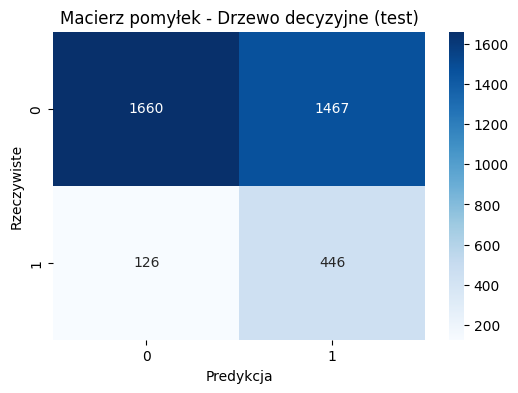

In [14]:
# Predykcja na zbiorze testowym
y_test_pred = dt.predict(X_test)

print("WYNIKI NA ZBIORZE TESTOWYM:")
print("=" * 80)

print("\nMacierz pomyłek:")
cm_test = confusion_matrix(Y_test, y_test_pred)
print(cm_test)

print("\nRaport klasyfikacji:")
print(classification_report(Y_test, y_test_pred))

plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Drzewo decyzyjne (test)")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

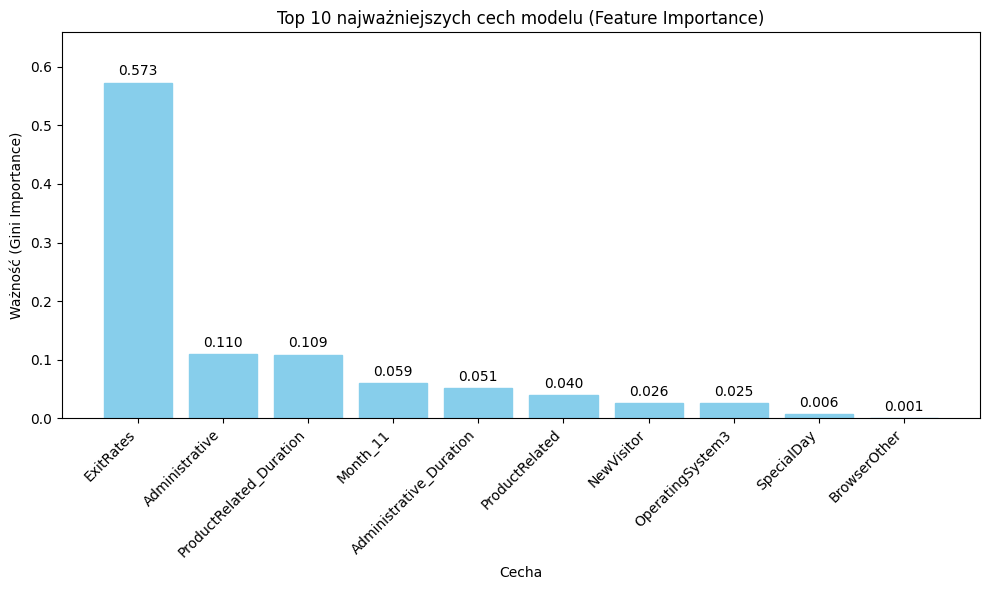

In [15]:
# Ważności cech z drzewa
importances = dt.feature_importances_
feature_names = X_train.columns  # Upewnij się, że używasz X_train lub X, jeśli X_test nie ma nazw kolumn

# DataFrame z ważnościami
feat_imp = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
}).sort_values(by='Ważność', ascending=False)

top10 = feat_imp.head(10)

# Wykres
plt.figure(figsize=(10, 6))
ax = plt.gca() # Pobranie aktualnych osi

# Tworzenie słupków
bars = ax.bar(top10['Cecha'], top10['Ważność'], color='skyblue', edgecolor='skyblue')

# Dodawanie etykiet słupków
ax.bar_label(bars, padding=3, fmt='%.3f') 

# Optymalizacja wyglądu
plt.xticks(rotation=45, ha='right') # Rotacja 45 stopni jest często czytelniejsza niż 90
plt.title("Top 10 najważniejszych cech modelu (Feature Importance)")
plt.ylabel("Ważność (Gini Importance)")
plt.xlabel("Cecha")

# Zwiększenie limitu osi Y, aby etykiety miały miejsce
plt.ylim(0, top10['Ważność'].max() * 1.15)
plt.tight_layout()
plt.show()